# import

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid")

**1. Muat Dataset**

In [ ]:
# Membaca dataset asli dari sheet 'Data' file csv
df = pd.read_csv("/content/furniture_10k_FINAL.csv", sep=';')

In [ ]:
df.head()

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address
0,2025-07-31,ORD00001,Customer_332,Kitchen Set,Dapur,9500000,1,0,9500000,60000,9560000,cancelled,"Kelurahan 120, Jakarta Pusat"
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat"
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat"
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor"
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sales_date        10000 non-null  object
 1   order_id          10000 non-null  object
 2   customer_name     10000 non-null  object
 3   product_name      10000 non-null  object
 4   category          10000 non-null  object
 5   price             10000 non-null  int64 
 6   quantity          10000 non-null  int64 
 7   discount          10000 non-null  object
 8   total             10000 non-null  int64 
 9   shipping_fee      10000 non-null  int64 
 10  total_sales       10000 non-null  int64 
 11  status            10000 non-null  object
 12  shipping_address  10000 non-null  object
dtypes: int64(5), object(8)
memory usage: 1015.8+ KB


# data cleansing

2. Ubah tipe data

In [ ]:
# Convert 'sales_date' to datetime
df['sales_date'] = pd.to_datetime(df['sales_date'])

# Convert 'discount' to numeric, coercing errors and filling NaN with 0
df['discount'] = pd.to_numeric(df['discount'], errors='coerce').fillna(0).astype(int)

# Display the info again to verify data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        10000 non-null  datetime64[ns]
 1   order_id          10000 non-null  object        
 2   customer_name     10000 non-null  object        
 3   product_name      10000 non-null  object        
 4   category          10000 non-null  object        
 5   price             10000 non-null  int64         
 6   quantity          10000 non-null  int64         
 7   discount          10000 non-null  int64         
 8   total             10000 non-null  int64         
 9   shipping_fee      10000 non-null  int64         
 10  total_sales       10000 non-null  int64         
 11  status            10000 non-null  object        
 12  shipping_address  10000 non-null  object        
dtypes: datetime64[ns](1), int64(6), object(6)
memory usage: 1015.8+ KB


Hasil:
1. tipe data sales_date berubah menjadi datetime
2. discount berubah menjadi int

**3. Hapus baris duplikat dan tangani Missing Values**

In [ ]:
# Memeriksa baris yang terduplikat sepenuhnya
print("\n=== JUMLAH BARIS DUPLIKAT ===")
print("Baris duplikat:", df.duplicated().sum())

# Memeriksa jumlah nilai kosong (null/NaN) di setiap kolom
print("\n=== JUMLAH NILAI KOSONG ===")
print(df.isnull().sum())

df["shipping_address"] = df["shipping_address"].fillna("Unknown")


=== JUMLAH BARIS DUPLIKAT ===
Baris duplikat: 0

=== JUMLAH NILAI KOSONG ===
sales_date          0
order_id            0
customer_name       0
product_name        0
category            0
price               0
quantity            0
discount            0
total               0
shipping_fee        0
total_sales         0
status              0
shipping_address    0
dtype: int64


Tidak ada data yang kosong dan duplikat

# Tantangan 2: AGGREGATION & PLOTTING

**1. Ekstrak data buat kolom baru city dari shipping_address**

In [ ]:
# Mengekstrak kota dari alamat pengiriman
df["city"] = df["shipping_address"].str.split(",").str[-1].str.strip()

# Menampilkan contoh kolom baru 'city'
print("\nHasil ekstraksi kota:")
print(df["city"].head(3))


Hasil ekstraksi kota:
0    Jakarta Pusat
1    Jakarta Pusat
2    Jakarta Pusat
Name: city, dtype: object


kolom city hanya berisi kota

**2. Filter status hanya pesanan "complete"**

In [ ]:
df = df[df["status"] == "completed"].copy()

**Simpan data yang sudah bersih ke file baru**

In [ ]:
# Menyimpan df ke file CSV baru tanpa menyertakan kolom indeks otomatis
df.to_csv("data_peralatan_dapur_clean.csv", index=False)
print("Berhasil menyimpan data bersih ke 'data_peraluan_dapur_clean.csv'!")

# Membaca kembali data bersih untuk memastikan semua aman, sekaligus mengurai kolom tanggal
df_clean_test = pd.read_csv("data_peralatan_dapur_clean.csv", parse_dates=['sales_date'])
print("\nStruktur file data bersih yang tersimpan:")
df_clean_test.info()

# Data baru
df_clean_test.head()

Berhasil menyimpan data bersih ke 'data_peraluan_dapur_clean.csv'!

Struktur file data bersih yang tersimpan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8972 entries, 0 to 8971
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        8972 non-null   datetime64[ns]
 1   order_id          8972 non-null   object        
 2   customer_name     8972 non-null   object        
 3   product_name      8972 non-null   object        
 4   category          8972 non-null   object        
 5   price             8972 non-null   int64         
 6   quantity          8972 non-null   int64         
 7   discount          8972 non-null   int64         
 8   total             8972 non-null   int64         
 9   shipping_fee      8972 non-null   int64         
 10  total_sales       8972 non-null   int64         
 11  status            8972 non-null   object        
 12  shipping_address  8972

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address,city
0,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
1,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat",Jakarta Pusat
2,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor",Bogor
3,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang",Tangerang
4,2025-01-11,ORD00006,Customer_793,Lemari Dapur,Dapur,1850000,1,0,1850000,60000,1910000,completed,"Kelurahan 176, Tangerang",Tangerang


**3. Total sales masing-masing kota**

In [ ]:
total_sales_by_city = df_clean_test.groupby('city')['total_sales'].sum().sort_values(ascending=False)
display(total_sales_by_city)

,total_sales
city,
Jakarta Utara,5068862000
Jakarta Barat,5021356500
Jakarta Pusat,4996988000
Depok,4854175000
Bogor,4811721500
Jakarta Selatan,4764095500
Jakarta Timur,4666865000
Tangerang Selatan,4544961500
Tangerang,4415711500


**4. Bar chart total sales**

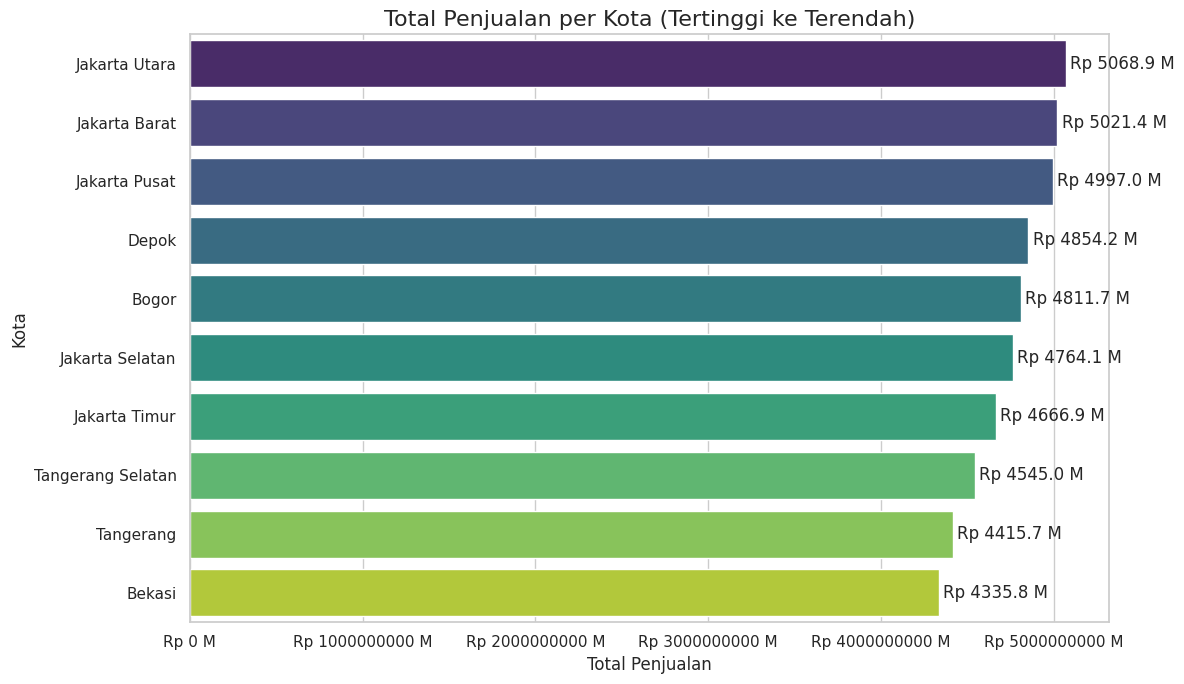

In [ ]:
import matplotlib.ticker as mtick

# Buat bar chart
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(y=total_sales_by_city.index, x=total_sales_by_city.values, hue=total_sales_by_city.index, palette='viridis', ax=ax, legend=False)

# Format sumbu-x sebagai Indonesian Rupiah dalam millions/billions
formatter = mtick.FormatStrFormatter('Rp %.0f M')
ax.xaxis.set_major_formatter(formatter)

# Tambahkan nilai label disetiap akhir bar
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'Rp {x/1_000_000:.1f} M', padding=3) # Adjust padding for horizontal bars

# Tambahkan judul and label
plt.title('Total Penjualan per Kota (Tertinggi ke Terendah)', fontsize=16)
plt.ylabel('Kota', fontsize=12)
plt.xlabel('Total Penjualan', fontsize=12)
plt.yticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

Dari bar chart terlihat kota dengan total sales **tertinggi** adalah kota **Jakarta Utara** dan yang **terendah adalah Bekasi**.

# Tantangan 3 : ADVANCED DASHBOARD CHALLENGE

**1. Filter pesanan promosi**

In [ ]:
# Menyaring pesanan yang memiliki diskon (karena df_clean_test sudah "completed")
df_diskon_sukses = df_clean_test[df_clean_test["discount"] > 0]


**2. Agregasi berdasarkan produk**

In [ ]:
# Mengelompokkan berdasarkan kategori produk dari semua pesanan yang completed (df_clean_test)
sales_by_category = df_clean_test.groupby("category").agg(
    total_omset=("total_sales", "sum"),
    rata_rata_diskon=("discount", "mean"),
    rata_rata_kuantitas=("quantity", "mean")
).reset_index()

# Mengurutkan dari omset tertinggi
sales_by_category = sales_by_category.sort_values(by="total_omset", ascending=False)

print("=== ANALISIS PENJUALAN PER KATEGORI (SEMUA PESANAN COMPLETED) ===")
display(sales_by_category)

=== ANALISIS PENJUALAN PER KATEGORI (SEMUA PESANAN COMPLETED) ===


,category,total_omset,rata_rata_diskon,rata_rata_kuantitas
1,Kamar Tidur,17499895000,0.0,2.010372
5,Ruang Tamu,12376515000,0.0,2.000000
0,Dapur,9380070000,0.0,1.942889
4,Ruang Makan,4783106000,0.0,2.010226
3,Ruang Kerja,1808565000,0.0,1.953933
2,Penyimpanan,1632355000,0.0,2.000000


Dapat dilihat **total sales paling tinggi** adalah **kamar tidur** dan yang **terendah** adalah **penyimpanan**

**3. Desain Dashboard Subplots**

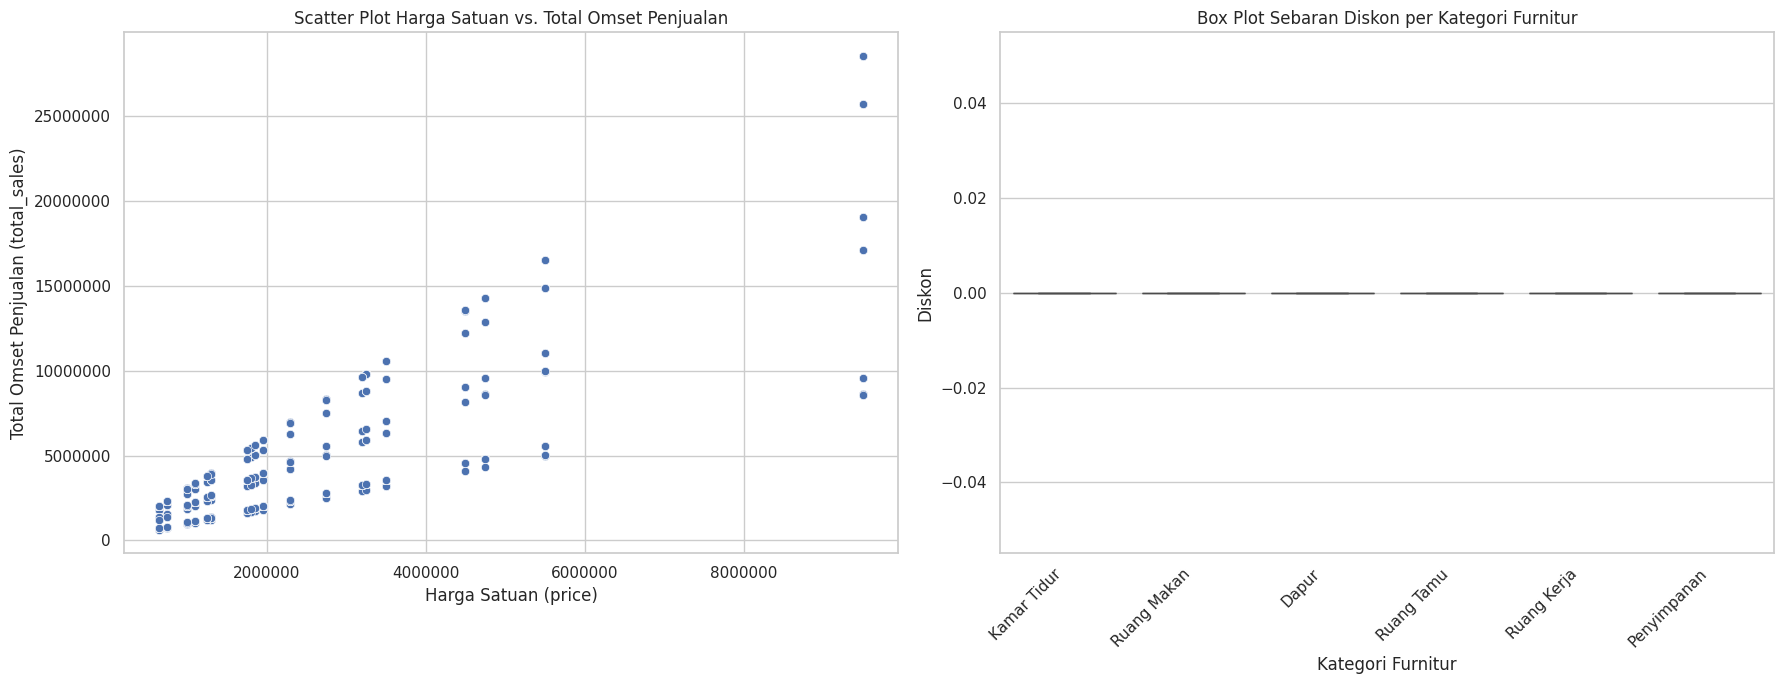

In [ ]:
# Buat gambar dengan 1 baris dan 2 kolom untuk subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Scatter plot diantara price dan total_sales
sns.scatterplot(x='price', y='total_sales', data=df_clean_test, ax=axes[0])
axes[0].set_title('Scatter Plot Harga Satuan vs. Total Omset Penjualan')
axes[0].set_xlabel('Harga Satuan (price)')
axes[0].set_ylabel('Total Omset Penjualan (total_sales)')
axes[0].ticklabel_format(style='plain', axis='y')
axes[0].ticklabel_format(style='plain', axis='x')

# Plot 2: Box plot sebaran diskon (discount) di setiap kategori furnitur
sns.boxplot(x='category', y='discount', data=df_clean_test, ax=axes[1])
axes[1].set_title('Box Plot Sebaran Diskon per Kategori Furnitur')
axes[1].set_xlabel('Kategori Furnitur')
axes[1].set_ylabel('Diskon')
axes[1].ticklabel_format(style='plain', axis='y')
axes[1].set_xticks(range(len(axes[1].get_xticklabels())))
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

**3. INSIGHT BISNIS DARI DAHSBOARD**

**Fokus pada Promosi Produk dengan Harga Satuan Tinggi dan Omset Baik:** Scatter plot menunjukkan korelasi positif antara harga satuan dan total omset penjualan. Ini berarti produk dengan harga lebih tinggi cenderung berkontribusi besar pada total pendapatan. Tim marketing dapat mengidentifikasi produk-produk 'bintang' ini dan merancang kampanye premium atau promosi nilai tambah yang menonjolkan kualitas dan fitur eksklusif untuk mendorong penjualan lebih lanjut dari segmen ini. Contohnya, membuat paket bundling eksklusif atau penawaran cicilan menarik untuk produk-produk kategori Kamar Tidur atau Ruang Tamu yang berharga tinggi.

**Evaluasi Ulang dan Optimalkan Strategi Diskon:** Box plot diskon menunjukkan bahwa hampir tidak ada diskon yang tercatat pada pesanan yang telah selesai (completed). Ini mengindikasikan bahwa diskon yang diberikan (jika ada) mungkin tidak efektif dalam mendorong konversi, atau tidak tercatat dengan baik, atau memang tidak ada diskon yang diaplikasikan pada transaksi yang berhasil. Tim marketing perlu menyelidiki lebih lanjut mengapa diskon tidak muncul pada pesanan yang sudah selesai. Jika diskon dimaksudkan untuk menjadi insentif, pertimbangkan untuk menerapkan diskon yang lebih strategis dan bertarget, misalnya diskon untuk produk yang kurang populer namun memiliki potensi, atau diskon khusus untuk pelanggan baru/loyal, dan pastikan efektivitasnya diukur berdasarkan pesanan yang berhasil diselesaikan.

**Manfaatkan Kategori Terlaris untuk Penjualan Silang (Cross-selling) dan Peningkatan Penjualan (Up-selling):** Data agregasi penjualan per kategori menunjukkan bahwa kategori seperti 'Kamar Tidur' dan 'Ruang Tamu' memiliki total omset tertinggi. Tim marketing dapat memanfaatkan popularitas kategori ini untuk strategi cross-selling (menawarkan produk pelengkap) atau up-selling (menawarkan versi produk yang lebih mahal/lengkap). Misalnya, ketika pelanggan membeli kasur, tawarkan bantal, sprei, atau nakas dari kategori Kamar Tidur. Atau, tawarkan paket 'Lengkapi Ruang Tamu Anda' dengan diskon terbatas jika membeli beberapa item sekaligus dari kategori tersebut.

#